In [5]:
from google.colab import files
uploaded = files.upload('Insurance.csv')


Saving Insurance.csv to Insurance.csv/Insurance.csv


In [ ]:
import pandas as pd

# Tải file CSV đã tải lên vào DataFrame của pandas
df = pd.read_csv('Insurance.csv')

# Hiển thị 5 dòng đầu tiên của DataFrame
display(df.head())

In [ ]:
# Kiểm tra các giá trị duy nhất cho những cột có thể là dữ liệu phân loại
print("Unique values for 'sex':", df['sex'].unique())
print("Unique values for 'smoker':", df['smoker'].unique())
print("Unique values for 'region':", df['region'].unique())
print("Unique values for 'insuranceclaim':", df['insuranceclaim'].unique())

In [ ]:
# Kiểm tra giá trị bị thiếu trong từng cột
missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# Tính ma trận tương quan
correlation_matrix = df.corr()

# Hiển thị ma trận tương quan
display(correlation_matrix)

# Trực quan hóa ma trận tương quan bằng heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create boxplots for numerical features to check for outliers
plt.figure(figsize=(20, 6))

plt.subplot(1, 4, 1)
sns.boxplot(y=df['age'])
plt.title('Boxplot of Age')

plt.subplot(1, 4, 2)
sns.boxplot(y=df['bmi'])
plt.title('Boxplot of BMI')

plt.subplot(1, 4, 3)
sns.boxplot(y=df['children'])
plt.title('Boxplot of Children')

plt.subplot(1, 4, 4)
sns.boxplot(y=df['charges'])
plt.title('Boxplot of Charges')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Đọc dữ liệu
df = pd.read_csv('Insurance.csv')

# 2. Vẽ Boxplot trước khi xóa để đối chiếu
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x=df['charges'])
plt.title('Trước khi xóa nhiễu')

# 3. Tính toán IQR để xác định ranh giới
Q1 = df['charges'].quantile(0.25)
Q3 = df['charges'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 4. Xóa dữ liệu nằm ngoài khoảng (Outliers)
df_clean = df[(df['charges'] >= lower_bound) & (df['charges'] <= upper_bound)]

# 5. Vẽ lại Boxplot sau khi đã làm sạch
plt.subplot(1, 2, 2)
sns.boxplot(x=df_clean['charges'])
plt.title('Sau khi xóa nhiễu')

plt.tight_layout()
plt.show()

print(f"Số dòng ban đầu: {len(df)}")
print(f"Số dòng sau khi làm sạch: {len(df_clean)}")

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Đọc dữ liệu
df = pd.read_csv('Insurance.csv')

# 2. Xác định các cột dạng số (để vẽ Boxplot)
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# 3. Hàm xử lý xóa nhiễu bằng IQR
def remove_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[column] >= lower) & (data[column] <= upper)]

# 4. Tạo dữ liệu sạch (df_clean) bằng cách lọc nhiễu cho các cột quan trọng (ví dụ: charges, bmi)
df_clean = df.copy()
for col in ['bmi', 'charges']: # Bạn có thể thêm các cột số khác vào danh sách này
    df_clean = remove_outliers(df_clean, col)

# 5. Vẽ biểu đồ so sánh
fig, axes = plt.subplots(nrows=len(numeric_cols), ncols=2, figsize=(12, 4 * len(numeric_cols)))

for i, col in enumerate(numeric_cols):
    # Cột bên trái: Trước khi làm sạch
    sns.boxplot(x=df[col], ax=axes[i, 0], color='salmon')
    axes[i, 0].set_title(f'{col} - Trước khi sạch')

    # Cột bên phải: Sau khi làm sạch
    sns.boxplot(x=df_clean[col], ax=axes[i, 1], color='skyblue')
    axes[i, 1].set_title(f'{col} - Sau khi sạch')

plt.tight_layout()
plt.show()

print(f"Dòng ban đầu: {len(df)} | Dòng sau khi sạch: {len(df_clean)}")


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập kiểu biểu đồ
sns.set_style("whitegrid")

# Xác định các cột số và cột phân loại (dựa trên EDA trước đó)
numerical_cols = ['age', 'bmi', 'charges']
categorical_cols = ['sex', 'children', 'smoker', 'region', 'insuranceclaim']

# Tạo biểu đồ cho từng cột

# Vẽ histogram cho các cột số
plt.figure(figsize=(20, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1)  # Sắp xếp thành 2 hàng, 2 cột
    sns.histplot(df[col], kde=True)
    plt.title(f'Phân phối của {col.capitalize()}')

plt.tight_layout()
plt.show()

# Vẽ countplot cho các cột phân loại
plt.figure(figsize=(20, 10))
for i, col in enumerate(categorical_cols):
    plt.subplot(2, 3, i + 1) # Arrange in 2 rows, 3 columns
    sns.countplot(x=df[col])
    plt.title(f'Count of {col.capitalize()}')
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tính ma trận tương quan
correlation_matrix = df.corr()

# Hiển thị ma trận tương quan
display(correlation_matrix)

# Trực quan hóa ma trận tương quan bằng heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()

### Violin Plots for Numerical Features

['.config', 'Insurance.csv', 'sample_data']


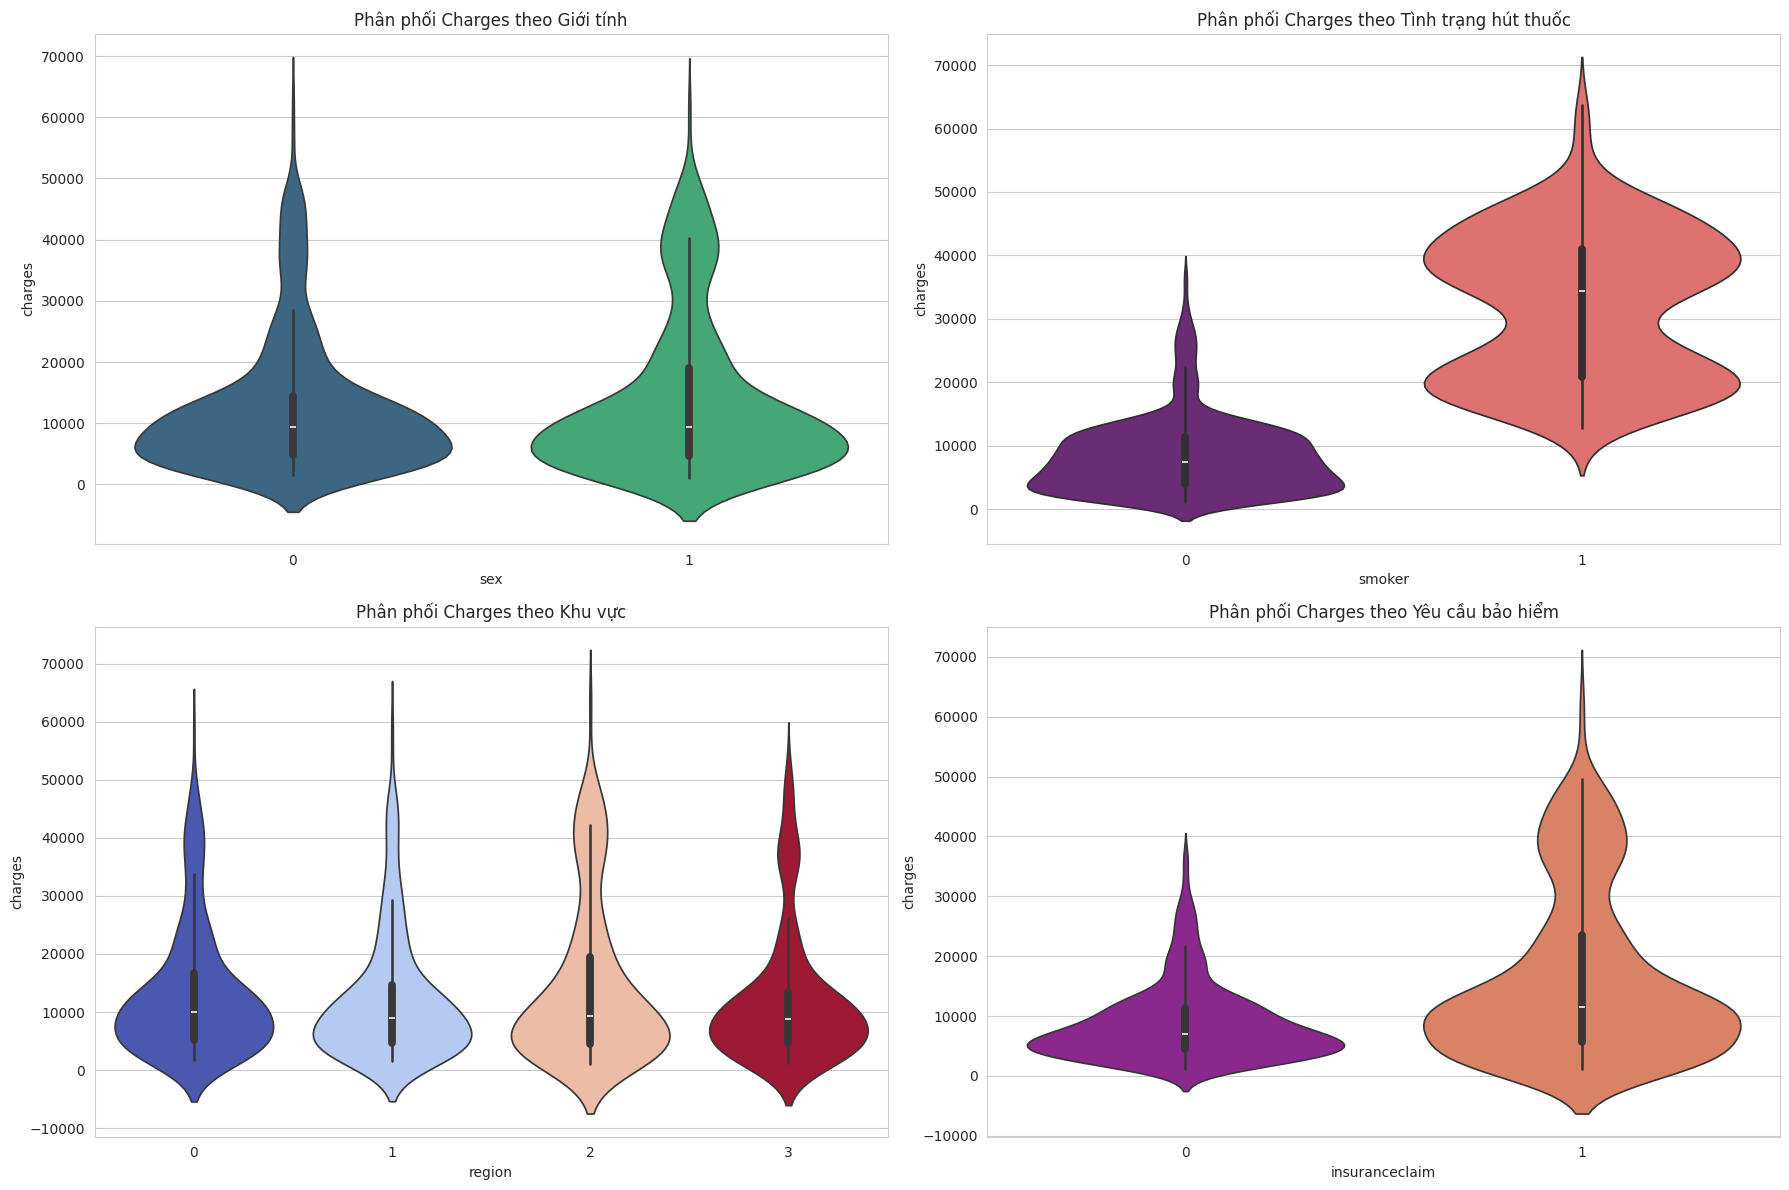

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Kiểm tra các file hiện có
print(os.listdir())

# Đọc file CSV
try:
    df
except NameError:
    df = pd.read_csv('Insurance.csv/Insurance.csv')

# Thiết lập style
sns.set_style("whitegrid")

# Vẽ violin plots
plt.figure(figsize=(18, 12))

# Charges theo giới tính
plt.subplot(2, 2, 1)
sns.violinplot(x='sex', y='charges', data=df, palette='viridis', hue='sex', legend=False)
plt.title('Phân phối Charges theo Giới tính')

# Charges theo tình trạng hút thuốc
plt.subplot(2, 2, 2)
sns.violinplot(x='smoker', y='charges', data=df, palette='magma', hue='smoker', legend=False)
plt.title('Phân phối Charges theo Tình trạng hút thuốc')

# Charges theo khu vực
plt.subplot(2, 2, 3)
sns.violinplot(x='region', y='charges', data=df, palette='coolwarm', hue='region', legend=False)
plt.title('Phân phối Charges theo Khu vực')

# Charges theo yêu cầu bảo hiểm
plt.subplot(2, 2, 4)
sns.violinplot(x='insuranceclaim', y='charges', data=df, palette='plasma', hue='insuranceclaim', legend=False)
plt.title('Phân phối Charges theo Yêu cầu bảo hiểm')

# Căn chỉnh layout
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

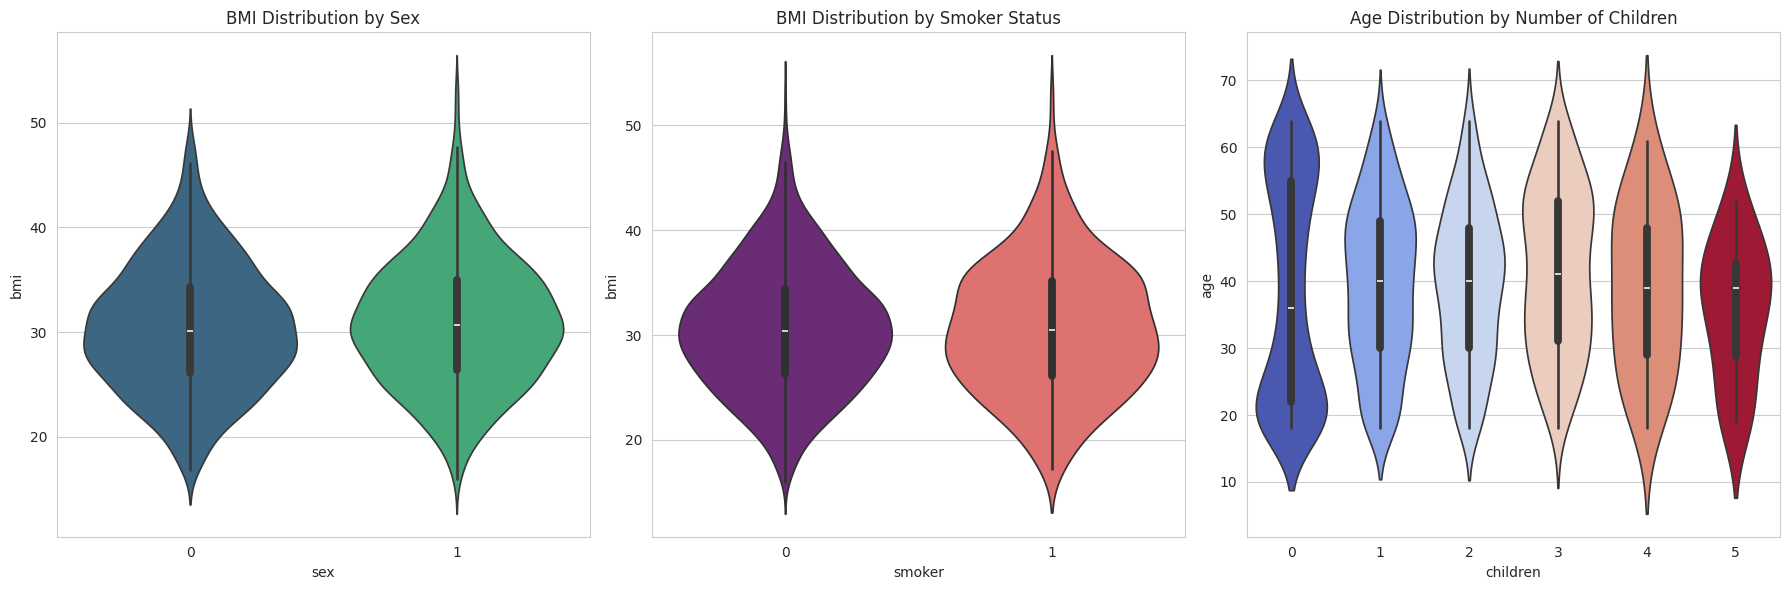

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Kiểm tra xem DataFrame df đã tồn tại chưa
try:
    df
except NameError:
    df = pd.read_csv('Insurance.csv/Insurance.csv')

# Tạo figure với kích thước phù hợp
plt.figure(figsize=(18, 6))

# Biểu đồ violin: Phân phối BMI theo giới tính
plt.subplot(1, 3, 1)
sns.violinplot(x='sex', y='bmi', data=df, palette='viridis', hue='sex', legend=False)
plt.title('BMI Distribution by Sex')
# Biểu đồ violin: Phân phối BMI theo tình trạng hút thuốc
plt.subplot(1, 3, 2)
sns.violinplot(x='smoker', y='bmi', data=df, palette='magma', hue='smoker', legend=False)
plt.title('BMI Distribution by Smoker Status')
# Biểu đồ violin: Phân phối độ tuổi theo số lượng con
plt.subplot(1, 3, 3)
sns.violinplot(x='children', y='age', data=df, palette='coolwarm', hue='children', legend=False)
plt.title('Age Distribution by Number of Children')
# Tự động căn chỉnh layout
plt.tight_layout()
# Hiển thị biểu đồ
plt.show()

### Scatter Plots for Key Relationships

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Đảm bảo df đã được tải trong trường hợp kernel bị reset hoặc chưa chạy trước đó
try:
    df
except NameError:
    df = pd.read_csv('Insurance.csv')

plt.figure(figsize=(15, 6))

# Biểu đồ phân tán giữa Age và Charges, tô màu theo tình trạng hút thuốc
plt.subplot(1, 2, 1)
sns.scatterplot(x='age', y='charges', hue='smoker', data=df, palette='viridis', alpha=0.7)
plt.title('Age vs. Charges (by Smoker Status)')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.grid(True, linestyle='--', alpha=0.6)

# Biểu đồ phân tán giữa BMI và Charges, tô màu theo tình trạng hút thuốc
plt.subplot(1, 2, 2)
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df, palette='magma', alpha=0.7)
plt.title('BMI vs. Charges (by Smoker Status)')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure df is loaded in case kernel reset or not run previously
try:
    df
except NameError:
    df = pd.read_csv('Insurance.csv')

plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='bmi', hue='smoker', data=df, palette='coolwarm', alpha=0.7)
plt.title('Age vs. BMI (by Smoker Status)')
plt.xlabel('Age')
plt.ylabel('BMI')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()